Num GPUs Available:  1
GPU is available, using GPU for training.
Found 27011 images belonging to 2 classes.
Found 4766 images belonging to 2 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 batch_normalization (BatchN  (None, 256)  

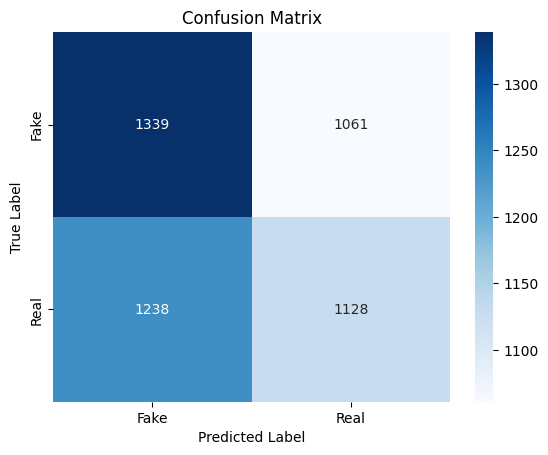

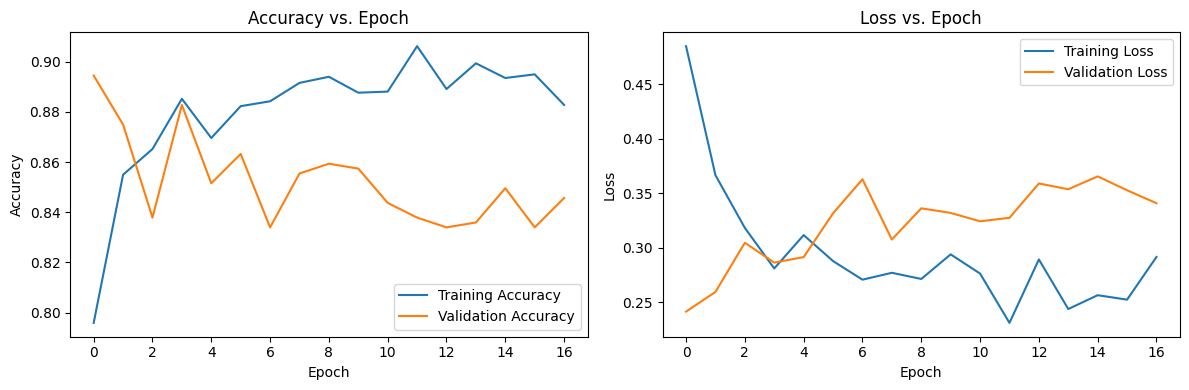

Found 8506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
532/532 [==============================] - 33s 61ms/step


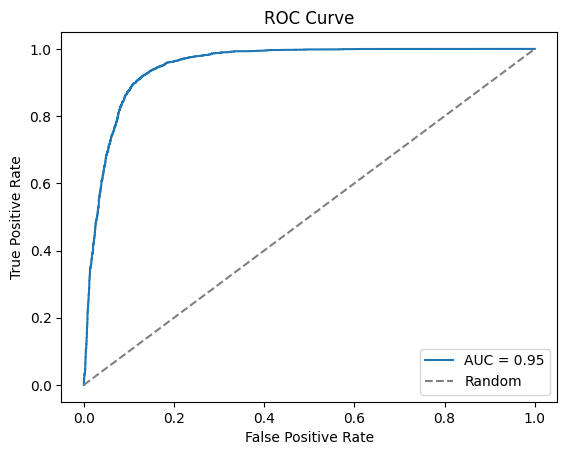

optimal threshold =  0.8853159
Classification Report:
              precision    recall  f1-score   support

        Fake       0.91      0.87      0.89      4037
        Real       0.89      0.92      0.90      4469

    accuracy                           0.90      8506
   macro avg       0.90      0.89      0.90      8506
weighted avg       0.90      0.90      0.90      8506

Confusion Matrix:
[[3505  532]
 [ 353 4116]]


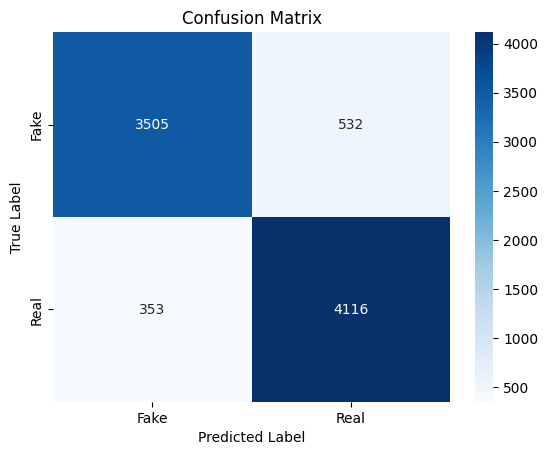

Evaluation Metrics:
accuracy: 0.8959557959087703
precision: 0.9085018144116123
recall: 0.8682189744860045
f1_score: 0.8879037365421153
auc: 0.9504635821936416


In [1]:
import model_fit_evaluate
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_input_mobilenetv2
import tensorflow as tf
import telebot
import time

if __name__ == '__main__':
    # 0. Config
    data_dir = '../balanced_data/train'
    image_size = (224, 224)
    batch_size = 4  
    epochs = 20

    train_generator, validation_generator = model_fit_evaluate.create_data_generators(data_dir, image_size, batch_size, preprocessing_function=preprocess_input_mobilenetv2)

    model = model_fit_evaluate.create_custom_model(
    base_model=MobileNetV2, 
    weights="imagenet",
    input_shape=(224, 224, 3), 
    num_classes=1, 
    trainable_base=False  
    )

    history = model_fit_evaluate.train_model(model, train_generator, validation_generator, epochs, batch_size, early_stopping_patience=5, reduce_lr_patience=4, reduce_lr_factor=0.25)

    model_fit_evaluate.evaluate_model(model, validation_generator)

    model_fit_evaluate.plot_training_history(history)
    
    test_data_dir = '../balanced_data/test' 

    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, test_data_dir, preprocess_input_mobilenetv2, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics[0].items():
        print(f"{metric}: {value}")


In [1]:
metrics[0]

NameError: name 'metrics' is not defined

Found 10110 images belonging to 2 classes.
632/632 [==============================] - 164s 260ms/step
[[1]
 [1]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Real       0.87      0.60      0.71      5089
        Fake       0.69      0.91      0.79      5021

    accuracy                           0.75     10110
   macro avg       0.78      0.76      0.75     10110
weighted avg       0.78      0.75      0.75     10110

Confusion Matrix:
[[3056 2033]
 [ 449 4572]]


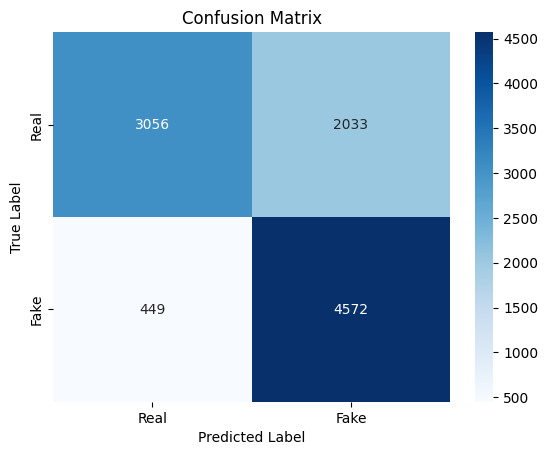

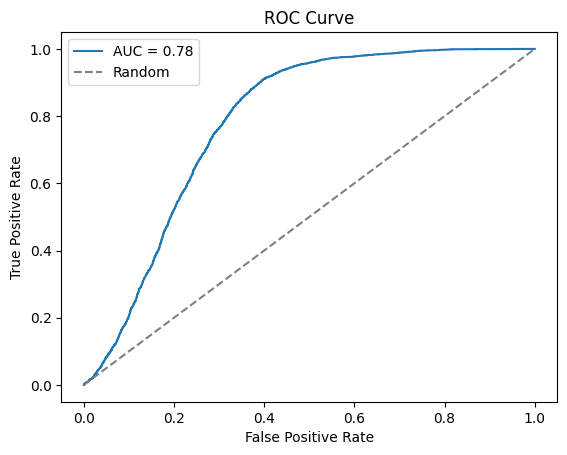

Evaluation Metrics:
accuracy: 0.7545004945598417
precision: 0.8718972895863053
recall: 0.6005109058754176
f1_score: 0.7111938561787293
auc: 0.7832076001955082


In [3]:
    metrics = model_fit_evaluate.evaluate_model_on_test_data(model, '../OF/test', preprocess_input_mobilenetv2, image_size=image_size, batch_size=16) #Added Image Size

    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

In [2]:
model.save('MobileNetV2_Deepfake.keras')